# Lab Day 1 — Nguyễn Thái Anh — 2A202602810
Hoàn thiện MLP, thiết kế thí nghiệm và kiểm chứng trên Forest CoverType.
Chạy **Restart & Run All** từ thư mục `submission_2A202602810/code/`.
Dữ liệu và scripts thuộc repo gốc; các kết quả nằm trong thư mục nộp.
Code chọn cấu hình bằng validation; chỉ Part 4 mới mở tập eval.

In [1]:
import os, sys, json, subprocess, time
from pathlib import Path
os.environ.setdefault("MPLCONFIGDIR", "/tmp/lab-matplotlib")
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from IPython.display import display, Image
from data import prepare_data, attach_eval
from model import MLP, EXPECTED_PARAMS, count_params, activation_stats
from train import DEFAULT_CFG, set_seed, evaluate, compute_loss, run_experiment, final_eval
from optimizer import build_optimizer
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx
from workflow import persist, run_store, overview, contrast

CODE_DIR = Path.cwd().resolve()
# Supports both the submitted notebook and the original repo/code notebook.
REPO_ROOT = CODE_DIR.parent if (CODE_DIR.parent / "scripts/split_data.py").exists() else CODE_DIR.parent.parent
OUT_DIR = REPO_ROOT / "submission_2A202602810"
for folder in ("figures", "results"):
    (OUT_DIR / folder).mkdir(parents=True, exist_ok=True)
os.environ['LAB_PROGRESS_LOG'] = str(OUT_DIR / 'run.log')
(OUT_DIR / 'run.log').write_text('')
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_num_threads(4)
START_TIME = time.perf_counter()
print('Python:', sys.executable, 'Conda:', os.environ.get('CONDA_DEFAULT_ENV'))
print('PyTorch:', torch.__version__, 'Device:', device, 'CPU threads:', torch.get_num_threads())
if device == 'cuda':
    print(torch.cuda.get_device_name(0))
else:
    print('CUDA unavailable; BF16 experiment uses CPU autocast. FP16 CUDA is not available.')


Python: /home/sakana/miniconda3/bin/python Conda: base
PyTorch: 2.10.0+cu128 Device: cuda CPU threads: 4
NVIDIA GeForce RTX 3060


## Part 0 — Dữ liệu
Tách train/validation phân tầng, seed 42. Chỉ tính mean/std từ 371 847 mẫu train;
giữ nguyên 44 cột one-hot. Không mở `eval.npz` trước Part 4.

In [2]:
if not all((REPO_ROOT / "data/processed" / f"{s}.npz").exists() for s in ('train', 'eval')):
    subprocess.run([sys.executable, 'scripts/split_data.py'], cwd=REPO_ROOT, check=True)
data = prepare_data(device, seed=42, processed_dir=REPO_ROOT / 'data/processed')
assert data['X_tr'].shape == (371847, 54) and data['X_val'].shape == (92962, 54)
assert 'X_eval' not in data
numeric = data['X_tr'][:, :10]
print('Train numeric means:', numeric.mean(0).cpu().numpy())
print('Train numeric stds:', numeric.std(0, correction=0).cpu().numpy())
assert torch.allclose(numeric.mean(0), torch.zeros(10, device=device), atol=1e-5)
assert torch.allclose(numeric.std(0, correction=0), torch.ones(10, device=device), atol=1e-5)
print('Train class counts:', torch.bincount(data['y_tr'], minlength=7).cpu().tolist())
print('Val class counts:', torch.bincount(data['y_val'], minlength=7).cpu().tolist())


Train: (371847, 54) Validation: (92962, 54) Majority val accuracy: 0.4875970826789441
Train numeric means: [ 4.1035127e-11 -5.7449179e-10 -2.6262481e-09  6.5656203e-10
 -2.7903886e-09 -4.1035127e-11 -1.5182997e-09 -2.9545291e-09
 -1.6003699e-09  1.7645104e-09]
Train numeric stds: [1.         1.         0.99999994 1.         0.99999994 1.
 1.         1.         1.         1.        ]
Train class counts: [135578, 181312, 22882, 1759, 6075, 11115, 13126]
Val class counts: [33894, 45328, 5721, 439, 1519, 2779, 3282]


## Part 1 — Model và kiểm tra sức khoẻ
Dự đoán: mạng trả logits `(B,7)`, tất cả gradient của He khác 0 và ghi nhớ được 20 mẫu.
`ln(7)` là loss của dự đoán đều; He có logits ngẫu nhiên không bằng 0 nên loss có thể lớn hơn.
Không sửa khởi tạo chỉ để ép phép đo gần mốc lý thuyết.

Linear (8, 256)
ReLU (8, 256)
Dropout (8, 256)
Linear (8, 128)
ReLU (8, 128)
Dropout (8, 128)
Linear (8, 7)
He step0 loss: 2.26906156539917 ln7: 1.9459101490553132
Zero logits step0: 1.9459096193313599
Gradient norms: {'net.0.weight': 0.5070549845695496, 'net.0.bias': 0.3422401249408722, 'net.3.weight': 2.021228551864624, 'net.3.bias': 0.44387364387512207, 'net.6.weight': 1.9604557752609253, 'net.6.bias': 0.5724555253982544}


Overfit 20: {'loss': 4.3928430386586115e-06, 'acc': 1.0, 'macro_f1': 0.7142857142857143}


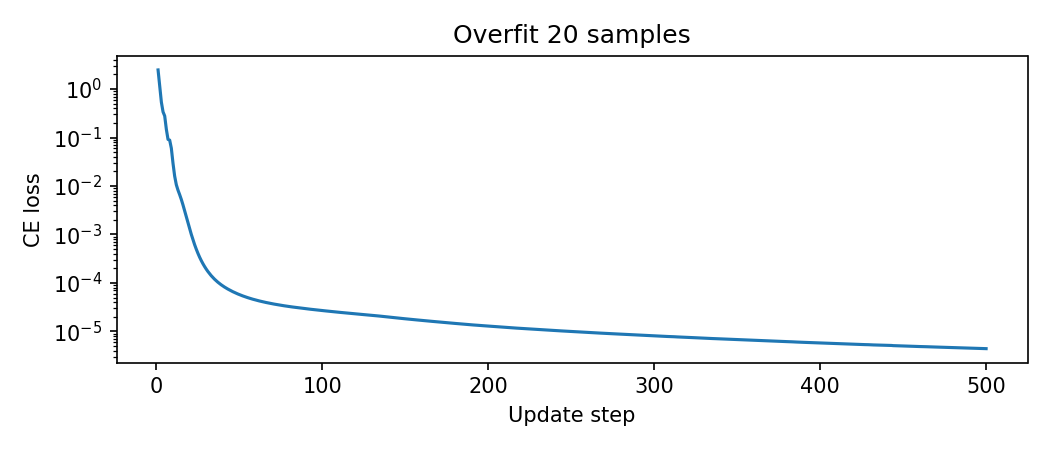

In [3]:
set_seed(1)
model = MLP().to(device)
assert count_params(model) == 47879
assert model(torch.randn(8,54,device=device)).shape == (8,7)
h = torch.randn(8,54,device=device)
for layer in model.net:
    h = layer(h)
    print(type(layer).__name__, tuple(h.shape))
health_loss = evaluate(model, data['X_val'], data['y_val'])['loss']
print('He step0 loss:', health_loss, 'ln7:', np.log(7))
zero_loss = evaluate(MLP(init='zeros').to(device), data['X_val'], data['y_val'])['loss']
print('Zero logits step0:', zero_loss)
assert abs(zero_loss - np.log(7)) < 1e-5
loss = compute_loss(model(data['X_tr'][:512]), data['y_tr'][:512], 'ce')
loss.backward()
gradients = {name:float(p.grad.norm()) for name,p in model.named_parameters()}
print('Gradient norms:', gradients)
assert all(v > 0 for v in gradients.values())

set_seed(1)
tiny = MLP().to(device)
tiny_opt = build_optimizer('adam', tiny.parameters(), lr=.01)
losses = []
for step in range(500):
    tiny_opt.zero_grad(set_to_none=True)
    loss = compute_loss(tiny(data['X_tr'][:20]), data['y_tr'][:20], 'ce')
    loss.backward()
    tiny_opt.step()
    losses.append(float(loss.detach()))
tiny_metrics = evaluate(tiny, data['X_tr'][:20], data['y_tr'][:20])
print('Overfit 20:', tiny_metrics)
assert tiny_metrics['acc'] == 1.0 and tiny_metrics['loss'] < .01
fig, ax = plt.subplots(figsize=(7,3))
ax.plot(range(1,501), losses)
ax.set(xlabel='Update step', ylabel='CE loss', title='Overfit 20 samples', yscale='log')
fig.tight_layout(); fig.savefig(OUT_DIR / 'figures/health_overfit20.png', dpi=150); plt.close(fig)
health = dict(step0_loss=health_loss, uniform_step0_loss=zero_loss,
              tiny_metrics=tiny_metrics, gradient_norms=gradients, parameters=count_params(model))
(OUT_DIR / 'health_checks.json').write_text(json.dumps(health, indent=2))
display(Image(filename=str(OUT_DIR / 'figures/health_overfit20.png')))


## Part 2 — Baseline và nhiễu seed
**Dự đoán trước:** SGD+momentum ở lr 0.05 hội tụ nhanh hơn lr 0.01 trong cùng 20 epoch,
nhưng có thể dao động hơn. Chọn lr có macro-F1 validation cao nhất tại checkpoint
có val loss thấp nhất. Chạy thêm seed 2, 3 với lr đã chọn; không chọn seed theo eval.
Mỗi epoch có 727 cập nhật, kể cả batch cuối 135 mẫu. Train loss đo trên cùng
50 000 mẫu cố định ở eval mode; val đo trên toàn bộ 92 962 mẫu.

In [4]:
base_trials = []
for lr in (.01, .05):
    cfg = {**DEFAULT_CFG, 'lr':lr, 'exp_id':f'tune-sgd-lr{lr}', 'group':'optimizer',
           'prediction':'lr .05 should converge faster than .01; larger lr may oscillate.'}
    base_trials.append(run_experiment(cfg, data))
base = max(base_trials, key=lambda r:r['summary']['val_macro_f1'])
other = next(r for r in base_trials if r is not base)
base['cfg'].update(exp_id='base-s1', group='baseline', description='Tuned SGD momentum baseline, seed 1')
base['cfg']['notes'] = 'lr selected using validation among .01 and .05; checkpoint by minimum val loss'
persist(base, OUT_DIR); persist(other, OUT_DIR)
results = [base, other]
base_cfg = {**base['cfg']}
for seed in (2,3):
    results.append(run_store({**base_cfg, 'seed':seed, 'exp_id':f'base-s{seed}',
                              'description':f'Baseline seed {seed}'}, data, OUT_DIR))
baselines = [r for r in results if r['cfg']['group']=='baseline']
base_f1 = np.array([r['summary']['val_macro_f1'] for r in baselines])
noise = 2 * base_f1.std(ddof=1)
print('Baseline lr:',base_cfg['lr'])
print('Val F1 mean +/- sample std:',base_f1.mean(),base_f1.std(ddof=1),'2 sigma:',noise)
display(overview(results))


tune-sgd-lr0.01: lr=0.01 precision=fp32 step0=2.269062


  epoch 01/20: train=0.5797 val=0.5787 acc=0.7569 F1=0.5106 grad=0.435 scaler_skips=0 0.3s


  epoch 02/20: train=0.5310 val=0.5299 acc=0.7760 F1=0.5838 grad=0.496 scaler_skips=0 0.3s


  epoch 03/20: train=0.4962 val=0.4971 acc=0.7895 F1=0.6104 grad=0.617 scaler_skips=0 0.3s


  epoch 04/20: train=0.4696 val=0.4705 acc=0.8007 F1=0.6390 grad=0.683 scaler_skips=0 0.3s


...

  epoch 18/20: train=0.2336 val=0.2528 acc=0.8970 F1=0.8269 grad=0.807 scaler_skips=0 0.3s


  epoch 19/20: train=0.2300 val=0.2506 acc=0.8975 F1=0.8361 grad=0.779 scaler_skips=0 0.3s


  epoch 20/20: train=0.2425 val=0.2618 acc=0.8933 F1=0.8259 grad=0.799 scaler_skips=0 0.3s


Baseline lr: 0.05
Val F1 mean +/- sample std: 0.8344771968520538 0.001913642233895671 2 sigma: 0.003827284467791342


,exp_id,step0_loss,best_epoch,val_acc,val_macro_f1,time_per_epoch_s,diverged
0,base-s1,2.269062,20,0.900110,0.834926,0.318971,False
1,tune-sgd-lr0.01,2.269062,19,0.867968,0.760059,0.319642,False
2,base-s2,1.978156,18,0.896754,0.832379,0.318646,False
3,base-s3,1.900540,19,0.897474,0.836127,0.319238,False


**Đối chiếu baseline:** bảng trên in lr được chọn và mean ± độ lệch chuẩn mẫu từ ba seed.
Ngưỡng 2σ chỉ là ước lượng thô. Nhận xét từng cấu hình ở Part 3 so với `base-s1`;
cột `beyond_noise` trong Excel so với trung bình ba seed theo công thức mẫu.

## Part 3 — Thí nghiệm
Mọi cấu hình dùng 20 epoch và seed 1, cùng split. Các biến thể loss, batch, dropout,
precision, init chỉ thay một yếu tố so với baseline. Optimizer được thử với hai lr riêng;
thay optimizer và lr được ghi rõ. Clipping chọn c từ percentile 75 gradient baseline.
Ở lr cao, so sánh cặp cùng lr có/không clip.

### Hàm mất mát
**Dự đoán trước:** MSE trên logits và nhãn one-hot có gradient khác CE; không so hai giá trị loss.
Dự đoán CE phù hợp phân loại và có macro-F1 tốt hơn trong cùng lịch huấn luyện.

In [5]:
specs = [dict(exp_id='loss-mse', group='loss', loss='mse', description='MSE on raw logits vs one-hot')]
for change in specs:
    cfg = {**base_cfg, **change, 'seed':1, 'prediction':'MSE trên logits và nhãn one-hot có gradient khác CE; không so hai giá trị loss.\nDự đoán CE phù hợp phân loại và có macro-F1 tốt hơn trong cùng lịch huấn luyện.'}
    r = run_store(cfg, data, OUT_DIR)
    results.append(r)
    print(contrast(r, base, noise))
    if cfg['group']=='init':
        print('Initial activation stds:', r['summary']['activation_stds'])
    if cfg['group']=='clipping':
        print('Mean fraction clipped:', np.mean(r['history']['clip_fraction']))
display(overview([r for r in results if r['cfg']['group']=='loss']))


loss-mse: lr=0.05 precision=fp32 step0=0.635850


  epoch 01/20: train=0.0520 val=0.0517 acc=0.7522 F1=0.4369 grad=0.067 scaler_skips=0 0.3s


  epoch 02/20: train=0.0479 val=0.0477 acc=0.7714 F1=0.4721 grad=0.052 scaler_skips=0 0.3s


  epoch 03/20: train=0.0452 val=0.0451 acc=0.7851 F1=0.4990 grad=0.057 scaler_skips=0 0.3s


  epoch 04/20: train=0.0436 val=0.0436 acc=0.7930 F1=0.5356 grad=0.064 scaler_skips=0 0.3s


...

  epoch 18/20: train=0.0326 val=0.0331 acc=0.8499 F1=0.6792 grad=0.105 scaler_skips=0 0.3s


  epoch 19/20: train=0.0320 val=0.0325 acc=0.8537 F1=0.6857 grad=0.111 scaler_skips=0 0.3s


  epoch 20/20: train=0.0316 val=0.0322 acc=0.8546 F1=0.6965 grad=0.108 scaler_skips=0 0.3s


loss-mse: val F1=0.696479; delta against base-s1=-0.138447; 2σ=0.003827; exceeds noise=True. Best epoch by minimum validation loss=20. Single-seed technique comparisons remain provisional.


,exp_id,step0_loss,best_epoch,val_acc,val_macro_f1,time_per_epoch_s,diverged
0,loss-mse,0.63585,20,0.854607,0.696479,0.338231,False


**Đối chiếu sau:** output trên ghi metric thật, chênh lệch và ngưỡng nhiễu. Phân tích cơ chế và kết quả có/không đúng dự đoán được tổng hợp tự động từ các run trong REPORT.md ở Part 4.

### Bộ tối ưu
**Dự đoán trước:** Adam với moment bậc một/hai có thể hội tụ nhanh ở lr .001 hoặc .003. Mỗi optimizer
được thử ít nhất hai lr: SGD momentum ở Part 2, Adam ở đây. Vì lr tối ưu khác nhau,
các run Adam đổi cả optimizer và lr; không suy ra thắng tuyệt đối từ một lr chung.

In [6]:
specs = [dict(exp_id=f'opt-adam-lr{lr}', group='optimizer', optimizer='adam', lr=lr, description='Adam lr sweep', notes='Changes optimizer and its tuned lr; betas=(.9,.999), eps=1e-8, wd=0') for lr in (.001,.003)]
for change in specs:
    cfg = {**base_cfg, **change, 'seed':1, 'prediction':'Adam với moment bậc một/hai có thể hội tụ nhanh ở lr .001 hoặc .003. Mỗi optimizer\nđược thử ít nhất hai lr: SGD momentum ở Part 2, Adam ở đây. Vì lr tối ưu khác nhau,\ncác run Adam đổi cả optimizer và lr; không suy ra thắng tuyệt đối từ một lr chung.'}
    r = run_store(cfg, data, OUT_DIR)
    results.append(r)
    print(contrast(r, base, noise))
    if cfg['group']=='init':
        print('Initial activation stds:', r['summary']['activation_stds'])
    if cfg['group']=='clipping':
        print('Mean fraction clipped:', np.mean(r['history']['clip_fraction']))
display(overview([r for r in results if r['cfg']['group']=='optimizer']))


opt-adam-lr0.001: lr=0.001 precision=fp32 step0=2.269062


  epoch 01/20: train=0.4879 val=0.4872 acc=0.7897 F1=0.6080 grad=0.550 scaler_skips=0 0.4s


  epoch 02/20: train=0.4210 val=0.4245 acc=0.8221 F1=0.6964 grad=0.695 scaler_skips=0 0.4s


  epoch 03/20: train=0.3866 val=0.3933 acc=0.8331 F1=0.7316 grad=0.755 scaler_skips=0 0.4s


  epoch 04/20: train=0.3550 val=0.3636 acc=0.8498 F1=0.7490 grad=0.767 scaler_skips=0 0.4s


...

  epoch 18/20: train=0.2031 val=0.2343 acc=0.9071 F1=0.8619 grad=0.698 scaler_skips=0 0.4s


  epoch 19/20: train=0.1902 val=0.2222 acc=0.9114 F1=0.8727 grad=0.712 scaler_skips=0 0.4s


  epoch 20/20: train=0.1811 val=0.2129 acc=0.9145 F1=0.8688 grad=0.709 scaler_skips=0 0.4s


opt-adam-lr0.003: val F1=0.868771; delta against base-s1=+0.033845; 2σ=0.003827; exceeds noise=True. Best epoch by minimum validation loss=20. Single-seed technique comparisons remain provisional.


,exp_id,step0_loss,best_epoch,val_acc,val_macro_f1,time_per_epoch_s,diverged
0,tune-sgd-lr0.01,2.269062,19,0.867968,0.760059,0.319642,False
1,opt-adam-lr0.001,2.269062,20,0.902950,0.846180,0.379954,False
2,opt-adam-lr0.003,2.269062,20,0.914546,0.868771,0.376742,False


**Đối chiếu sau:** output trên ghi metric thật, chênh lệch và ngưỡng nhiễu. Phân tích cơ chế và kết quả có/không đúng dự đoán được tổng hợp tự động từ các run trong REPORT.md ở Part 4.

### Batch size
**Dự đoán trước:** Batch 256 có 1 453 cập nhật/epoch thay cho 727. Dự đoán tăng số cập nhật giúp
học thêm chi tiết nhưng tốn thời gian và gradient nhiễu hơn; giữ nguyên lr để thử riêng batch.

In [7]:
specs = [dict(exp_id='batch-256', group='hparam', batch=256, description='Half batch; fixed lr; more updates')]
for change in specs:
    cfg = {**base_cfg, **change, 'seed':1, 'prediction':'Batch 256 có 1 453 cập nhật/epoch thay cho 727. Dự đoán tăng số cập nhật giúp\nhọc thêm chi tiết nhưng tốn thời gian và gradient nhiễu hơn; giữ nguyên lr để thử riêng batch.'}
    r = run_store(cfg, data, OUT_DIR)
    results.append(r)
    print(contrast(r, base, noise))
    if cfg['group']=='init':
        print('Initial activation stds:', r['summary']['activation_stds'])
    if cfg['group']=='clipping':
        print('Mean fraction clipped:', np.mean(r['history']['clip_fraction']))
display(overview([r for r in results if r['cfg']['group']=='hparam']))


batch-256: lr=0.05 precision=fp32 step0=2.269062


  epoch 01/20: train=0.4848 val=0.4857 acc=0.7930 F1=0.6406 grad=0.645 scaler_skips=0 0.7s


  epoch 02/20: train=0.3974 val=0.4017 acc=0.8325 F1=0.7092 grad=0.709 scaler_skips=0 0.6s


  epoch 03/20: train=0.3603 val=0.3682 acc=0.8448 F1=0.7443 grad=0.728 scaler_skips=0 0.6s


  epoch 04/20: train=0.3235 val=0.3354 acc=0.8622 F1=0.7762 grad=0.744 scaler_skips=0 0.7s


...

  epoch 18/20: train=0.2313 val=0.2529 acc=0.8993 F1=0.8456 grad=0.752 scaler_skips=0 0.6s


  epoch 19/20: train=0.2103 val=0.2349 acc=0.9062 F1=0.8545 grad=0.750 scaler_skips=0 0.6s


  epoch 20/20: train=0.2034 val=0.2251 acc=0.9106 F1=0.8612 grad=0.749 scaler_skips=0 0.6s


batch-256: val F1=0.861197; delta against base-s1=+0.026271; 2σ=0.003827; exceeds noise=True. Best epoch by minimum validation loss=20. Single-seed technique comparisons remain provisional.


,exp_id,step0_loss,best_epoch,val_acc,val_macro_f1,time_per_epoch_s,diverged
0,batch-256,2.269062,20,0.910555,0.861197,0.647809,False


**Đối chiếu sau:** output trên ghi metric thật, chênh lệch và ngưỡng nhiễu. Phân tích cơ chế và kết quả có/không đúng dự đoán được tổng hợp tự động từ các run trong REPORT.md ở Part 4.

### Dropout
**Dự đoán trước:** q=.1 là regularization nhẹ. Nếu baseline chưa quá khớp, dropout có thể giảm khả năng học;
chỉ kết luận giúp khi val tốt hơn và cân nhắc 2σ. Train/val loss đều đo khi dropout tắt.

In [8]:
specs = [dict(exp_id='drop-01', group='dropout', dropout=.1, description='Dropout p=.1 after hidden ReLU')]
for change in specs:
    cfg = {**base_cfg, **change, 'seed':1, 'prediction':'q=.1 là regularization nhẹ. Nếu baseline chưa quá khớp, dropout có thể giảm khả năng học;\nchỉ kết luận giúp khi val tốt hơn và cân nhắc 2σ. Train/val loss đều đo khi dropout tắt.'}
    r = run_store(cfg, data, OUT_DIR)
    results.append(r)
    print(contrast(r, base, noise))
    if cfg['group']=='init':
        print('Initial activation stds:', r['summary']['activation_stds'])
    if cfg['group']=='clipping':
        print('Mean fraction clipped:', np.mean(r['history']['clip_fraction']))
display(overview([r for r in results if r['cfg']['group']=='dropout']))


drop-01: lr=0.05 precision=fp32 step0=2.269062


  epoch 01/20: train=0.5166 val=0.5138 acc=0.7805 F1=0.5778 grad=0.393 scaler_skips=0 0.4s


  epoch 02/20: train=0.4675 val=0.4674 acc=0.8040 F1=0.6443 grad=0.386 scaler_skips=0 0.3s


  epoch 03/20: train=0.4283 val=0.4307 acc=0.8172 F1=0.6747 grad=0.396 scaler_skips=0 0.3s


  epoch 04/20: train=0.4048 val=0.4087 acc=0.8280 F1=0.7023 grad=0.395 scaler_skips=0 0.3s


...

  epoch 18/20: train=0.2696 val=0.2784 acc=0.8875 F1=0.8151 grad=0.438 scaler_skips=0 0.3s


  epoch 19/20: train=0.2659 val=0.2771 acc=0.8883 F1=0.8180 grad=0.437 scaler_skips=0 0.3s


  epoch 20/20: train=0.2626 val=0.2722 acc=0.8900 F1=0.8278 grad=0.437 scaler_skips=0 0.3s


drop-01: val F1=0.827773; delta against base-s1=-0.007153; 2σ=0.003827; exceeds noise=True. Best epoch by minimum validation loss=20. Single-seed technique comparisons remain provisional.


,exp_id,step0_loss,best_epoch,val_acc,val_macro_f1,time_per_epoch_s,diverged
0,drop-01,2.269062,20,0.889955,0.827773,0.345897,False


**Đối chiếu sau:** output trên ghi metric thật, chênh lệch và ngưỡng nhiễu. Phân tích cơ chế và kết quả có/không đúng dự đoán được tổng hợp tự động từ các run trong REPORT.md ở Part 4.

### Gradient clipping
**Dự đoán trước:** Chọn c ở percentile 75 của gradient toàn cục baseline: dự kiến có clip trong một phần bước.
Tăng lr 10 lần rồi so có/không clip để xem clipping chặn gai gradient; clipping
không đảm bảo cứu được bước cập nhật quá lớn.

In [9]:
clip_c = float(np.percentile(base['grad_norm_steps'], 75))
print('Clip c from baseline p75:', clip_c)
specs = [dict(exp_id='clip-normal', group='clipping', clip_norm=clip_c, description='Clip at baseline p75'), dict(exp_id='highlr-no-clip', group='clipping', lr=base_cfg['lr']*10, description='10x lr without clipping', notes='High-lr control; only lr changes vs baseline'), dict(exp_id='highlr-clip', group='clipping', lr=base_cfg['lr']*10, clip_norm=clip_c, description='10x lr with clipping', notes='Compared against highlr-no-clip; lr and clip change vs baseline')]
for change in specs:
    cfg = {**base_cfg, **change, 'seed':1, 'prediction':'Chọn c ở percentile 75 của gradient toàn cục baseline: dự kiến có clip trong một phần bước.\nTăng lr 10 lần rồi so có/không clip để xem clipping chặn gai gradient; clipping\nkhông đảm bảo cứu được bước cập nhật quá lớn.'}
    r = run_store(cfg, data, OUT_DIR)
    results.append(r)
    print(contrast(r, base, noise))
    if cfg['group']=='init':
        print('Initial activation stds:', r['summary']['activation_stds'])
    if cfg['group']=='clipping':
        print('Mean fraction clipped:', np.mean(r['history']['clip_fraction']))
display(overview([r for r in results if r['cfg']['group']=='clipping']))


Clip c from baseline p75: 0.8710557669401169
clip-normal: lr=0.05 precision=fp32 step0=2.269062


  epoch 01/20: train=0.4953 val=0.4950 acc=0.7865 F1=0.6206 grad=0.583 scaler_skips=0 0.3s


  epoch 02/20: train=0.4285 val=0.4345 acc=0.8157 F1=0.6893 grad=0.716 scaler_skips=0 0.3s


  epoch 03/20: train=0.3953 val=0.4023 acc=0.8294 F1=0.7050 grad=0.761 scaler_skips=0 0.3s


  epoch 04/20: train=0.3691 val=0.3772 acc=0.8432 F1=0.7351 grad=0.811 scaler_skips=0 0.3s


...

  epoch 18/20: train=0.2297 val=0.2559 acc=0.9001 F1=0.8321 grad=0.284 scaler_skips=0 0.3s


  epoch 19/20: train=0.2123 val=0.2379 acc=0.9084 F1=0.8556 grad=0.286 scaler_skips=0 0.3s


  epoch 20/20: train=0.2211 val=0.2388 acc=0.9067 F1=0.8382 grad=0.283 scaler_skips=0 0.3s


highlr-clip: val F1=0.855244; delta against base-s1=+0.020318; 2σ=0.003827; exceeds noise=True. Best epoch by minimum validation loss=16. Single-seed technique comparisons remain provisional.
Mean fraction clipped: 0.0007565337001375517


,exp_id,step0_loss,best_epoch,val_acc,val_macro_f1,time_per_epoch_s,diverged
0,clip-normal,2.269062,20,0.897786,0.832437,0.326871,False
1,highlr-no-clip,2.269062,20,0.899185,0.838530,0.325688,False
2,highlr-clip,2.269062,16,0.909554,0.855244,0.317715,False


**Đối chiếu sau:** output trên ghi metric thật, chênh lệch và ngưỡng nhiễu. Phân tích cơ chế và kết quả có/không đúng dự đoán được tổng hợp tự động từ các run trong REPORT.md ở Part 4.

### Mixed precision
**Dự đoán trước:** RTX 3060 có thể tăng tốc phép nhân FP16/BF16; MLP nhỏ chịu chi phí kernel,
đo gradient và đồng bộ nên thời gian toàn epoch có thể không giảm. Tham số và validation vẫn FP32.
FP16 dùng GradScaler và unscale trước đo/clip; BF16 không dùng scaler.
Nếu chạy CPU: BF16 có thể chậm hơn; FP16 được bỏ qua và ghi lý do.
FP16 là phép đo bổ sung cho phần precision, không tham gia chọn cấu hình cuối đã khoá bằng val.

In [10]:
specs = [dict(exp_id='amp-bf16', group='amp', precision='bf16', description='BF16 autocast; FP32 parameters and validation', notes='CPU fallback if CUDA unavailable; RSS cumulative only on CPU')]
if device=='cuda':
    specs.append(dict(exp_id='amp-fp16',group='amp',precision='fp16',description='FP16 autocast with GradScaler',notes='Supplemental precision diagnostic; excluded from final selection'))
else:
    print('FP16 skipped: CUDA required. Reason recorded in amp-bf16 notes.')
for change in specs:
    cfg = {**base_cfg, **change, 'seed':1, 'prediction':'AMP may accelerate GEMMs, but kernel, gradient and synchronization overhead can dominate this small MLP; measure full epoch including FP32 validation. FP16 is a supplemental diagnostic excluded from final selection.'}
    r = run_store(cfg, data, OUT_DIR)
    results.append(r)
    print(contrast(r, base, noise))
    if cfg['group']=='init':
        print('Initial activation stds:', r['summary']['activation_stds'])
    if cfg['group']=='clipping':
        print('Mean fraction clipped:', np.mean(r['history']['clip_fraction']))
display(overview([r for r in results if r['cfg']['group']=='amp']))


amp-bf16: lr=0.05 precision=bf16 step0=2.269062


  epoch 01/20: train=0.4987 val=0.4977 acc=0.7850 F1=0.6147 grad=0.559 scaler_skips=0 0.4s


  epoch 02/20: train=0.4278 val=0.4332 acc=0.8186 F1=0.6892 grad=0.677 scaler_skips=0 0.4s


  epoch 03/20: train=0.3976 val=0.4047 acc=0.8284 F1=0.7146 grad=0.743 scaler_skips=0 0.4s


  epoch 04/20: train=0.3706 val=0.3782 acc=0.8420 F1=0.7252 grad=0.776 scaler_skips=0 0.4s


...

  epoch 18/20: train=0.2461 val=0.2642 acc=0.8942 F1=0.8337 grad=0.813 scaler_skips=0 0.4s


  epoch 19/20: train=0.2338 val=0.2554 acc=0.8960 F1=0.8314 grad=0.802 scaler_skips=0 0.4s


  epoch 20/20: train=0.2270 val=0.2464 acc=0.9005 F1=0.8420 grad=0.812 scaler_skips=1 0.4s


amp-fp16: val F1=0.842037; delta against base-s1=+0.007112; 2σ=0.003827; exceeds noise=True. Best epoch by minimum validation loss=20. Single-seed technique comparisons remain provisional.


,exp_id,step0_loss,best_epoch,val_acc,val_macro_f1,time_per_epoch_s,diverged
0,amp-bf16,2.269062,20,0.902068,0.844011,0.395366,False
1,amp-fp16,2.269062,20,0.900540,0.842037,0.445341,False


**Đối chiếu sau:** output trên ghi metric thật, chênh lệch và ngưỡng nhiễu. Phân tích cơ chế và kết quả có/không đúng dự đoán được tổng hợp tự động từ các run trong REPORT.md ở Part 4.

### Khởi tạo
**Dự đoán trước:** Zeros làm các neuron đối xứng; ReLU(0) có đạo hàm 0 nên lớp ẩn không học,
chỉ bias đầu ra học tần suất lớp. Normal std=.01 có kích hoạt nhỏ, có thể học chậm.
Xavier dùng variance 2/(fan_in+fan_out), He dùng 2/fan_in cho mọi Linear.
Ghi std sau từng Linear trước cập nhật để kiểm tra độ lớn tín hiệu.

In [11]:
specs = [dict(exp_id=f'init-{init}', group='init', init=init, description=f'Initialization {init}') for init in ('zeros','normal','xavier')]
for change in specs:
    cfg = {**base_cfg, **change, 'seed':1, 'prediction':'Zeros làm các neuron đối xứng; ReLU(0) có đạo hàm 0 nên lớp ẩn không học,\nchỉ bias đầu ra học tần suất lớp. Normal std=.01 có kích hoạt nhỏ, có thể học chậm.\nXavier dùng variance 2/(fan_in+fan_out), He dùng 2/fan_in cho mọi Linear.\nGhi std sau từng Linear trước cập nhật để kiểm tra độ lớn tín hiệu.'}
    r = run_store(cfg, data, OUT_DIR)
    results.append(r)
    print(contrast(r, base, noise))
    if cfg['group']=='init':
        print('Initial activation stds:', r['summary']['activation_stds'])
    if cfg['group']=='clipping':
        print('Mean fraction clipped:', np.mean(r['history']['clip_fraction']))
display(overview([r for r in results if r['cfg']['group']=='init']))


init-zeros: lr=0.05 precision=fp32 step0=1.945910


  epoch 01/20: train=1.2099 val=1.2053 acc=0.4876 F1=0.0936 grad=0.043 scaler_skips=0 0.3s


  epoch 02/20: train=1.2099 val=1.2053 acc=0.4876 F1=0.0936 grad=0.033 scaler_skips=0 0.3s


  epoch 03/20: train=1.2102 val=1.2057 acc=0.4876 F1=0.0936 grad=0.033 scaler_skips=0 0.3s


  epoch 04/20: train=1.2099 val=1.2055 acc=0.4876 F1=0.0936 grad=0.033 scaler_skips=0 0.3s


...

  epoch 18/20: train=0.2422 val=0.2573 acc=0.8963 F1=0.8283 grad=0.834 scaler_skips=0 0.3s


  epoch 19/20: train=0.2402 val=0.2599 acc=0.8940 F1=0.8202 grad=0.840 scaler_skips=0 0.3s


  epoch 20/20: train=0.2519 val=0.2680 acc=0.8942 F1=0.8298 grad=0.839 scaler_skips=0 0.3s


init-xavier: val F1=0.828302; delta against base-s1=-0.006624; 2σ=0.003827; exceeds noise=True. Best epoch by minimum validation loss=18. Single-seed technique comparisons remain provisional.
Initial activation stds: [0.2780507802963257, 0.220273956656456, 0.19688622653484344]


,exp_id,step0_loss,best_epoch,val_acc,val_macro_f1,time_per_epoch_s,diverged
0,init-zeros,1.945910,15,0.487597,0.093650,0.321169,False
1,init-normal,1.945996,20,0.890751,0.824713,0.322464,False
2,init-xavier,2.022176,18,0.896323,0.828302,0.323145,False


**Đối chiếu sau:** output trên ghi metric thật, chênh lệch và ngưỡng nhiễu. Phân tích cơ chế và kết quả có/không đúng dự đoán được tổng hợp tự động từ các run trong REPORT.md ở Part 4.

In [12]:
for group in ('baseline','loss','optimizer','hparam','dropout','clipping','amp','init'):
    compare = [base] + [r for r in results if r is not base and r['cfg']['group']==group]
    plot_compare(compare, 'val_macro_f1', OUT_DIR / f'figures/compare_{group}.png', f'{group}: validation macro-F1')
display(overview(results))


,exp_id,step0_loss,best_epoch,val_acc,val_macro_f1,time_per_epoch_s,diverged
0,base-s1,2.269062,20,0.900110,0.834926,0.318971,False
1,tune-sgd-lr0.01,2.269062,19,0.867968,0.760059,0.319642,False
2,base-s2,1.978156,18,0.896754,0.832379,0.318646,False
3,base-s3,1.900540,19,0.897474,0.836127,0.319238,False
4,loss-mse,0.635850,20,0.854607,0.696479,0.338231,False
5,opt-adam-lr0.001,2.269062,20,0.902950,0.846180,0.379954,False
6,opt-adam-lr0.003,2.269062,20,0.914546,0.868771,0.376742,False
7,batch-256,2.269062,20,0.910555,0.861197,0.647809,False
8,drop-01,2.269062,20,0.889955,0.827773,0.345897,False
9,clip-normal,2.269062,20,0.897786,0.832437,0.326871,False


## Part 4 — Chọn cấu hình bằng val, đánh giá cuối và nộp bài
Cố định cấu hình tốt nhất trong các **seed 1** không diverged, theo macro-F1 val
ở checkpoint val loss thấp nhất. Seed 2/3 baseline chỉ để đo nhiễu.
Ghi quyết định xuống JSON trước khi mở eval. Chấm đúng script giảng viên cho baseline
và cấu hình cuối; không thay đổi cấu hình sau khi thấy điểm eval.

In [13]:
eligible = [r for r in results if r['cfg']['seed']==1 and not r['summary']['diverged'] and r['cfg']['exp_id']!='amp-fp16']
final = max(eligible, key=lambda r:r['summary']['val_macro_f1'])
selection = dict(baseline_exp_id=base['cfg']['exp_id'], final_exp_id=final['cfg']['exp_id'],
                 criterion='highest validation macro-F1 at minimum validation loss; seed 1 only; supplemental FP16 excluded',
                 final_cfg=final['cfg'], final_val_macro_f1=final['summary']['val_macro_f1'])
(OUT_DIR / 'selection.json').write_text(json.dumps(selection, ensure_ascii=False, indent=2))
print('Locked selection BEFORE opening eval:', selection)
attach_eval(data)
assert data['X_eval'].shape == (116203,54)
scores = {}
for label, result in [('baseline',base), ('final',final)]:
    pred = OUT_DIR / ('predictions_eval.csv' if label=='final' else 'predictions_baseline.csv')
    out = OUT_DIR / ('eval_result.json' if label=='final' else 'baseline_eval_result.json')
    # Identical deterministic reruns reuse the official scores after verifying predictions.
    previous_pred = pred.read_bytes() if pred.exists() and out.exists() else None
    final_eval(result['cfg'], result, data, pred)
    if previous_pred is not None and pred.read_bytes() == previous_pred:
        print('Predictions identical to previous execution; reuse official result:', out.name)
        scores[result['cfg']['exp_id']] = json.loads(out.read_text())
        continue
    subprocess.run([sys.executable, 'scripts/evaluate.py', '--pred',str(pred),'--out',str(out)],
                   cwd=REPO_ROOT, check=True)
    scores[result['cfg']['exp_id']] = json.loads(out.read_text())
print('Final official metrics:',scores[final['cfg']['exp_id']])


Locked selection BEFORE opening eval: {'baseline_exp_id': 'base-s1', 'final_exp_id': 'opt-adam-lr0.003', 'criterion': 'highest validation macro-F1 at minimum validation loss; seed 1 only; supplemental FP16 excluded', 'final_cfg': {'exp_id': 'opt-adam-lr0.003', 'group': 'optimizer', 'description': 'Adam lr sweep', 'loss': 'ce', 'optimizer': 'adam', 'lr': 0.003, 'weight_decay': 0.0, 'momentum': 0.9, 'batch': 512, 'epochs': 20, 'hidden': (256, 128), 'dropout': 0.0, 'init': 'he', 'clip_norm': None, 'precision': 'fp32', 'seed': 1, 'train_probe_size': 50000, 'scheduler': None, 'prediction': 'Adam với moment bậc một/hai có thể hội tụ nhanh ở lr .001 hoặc .003. Mỗi optimizer\nđược thử ít nhất hai lr: SGD momentum ở Part 2, Adam ở đây. Vì lr tối ưu khác nhau,\ncác run Adam đổi cả optimizer và lr; không suy ra thắng tuyệt đối từ một lr chung.', 'notes': 'Changes optimizer and its tuned lr; betas=(.9,.999), eps=1e-8, wd=0'}, 'final_val_macro_f1': 0.8687706103378063}
Predictions identical to previ

,cls,support,precision,recall,f1
0,0,42368,0.898078,0.920907,0.909349
1,1,56661,0.927721,0.922645,0.925176
2,2,7151,0.918174,0.908544,0.913334
3,3,549,0.851577,0.836066,0.843750
4,4,1899,0.868775,0.679831,0.762777
5,5,3473,0.836056,0.839908,0.837978
6,6,4102,0.953105,0.886884,0.918803


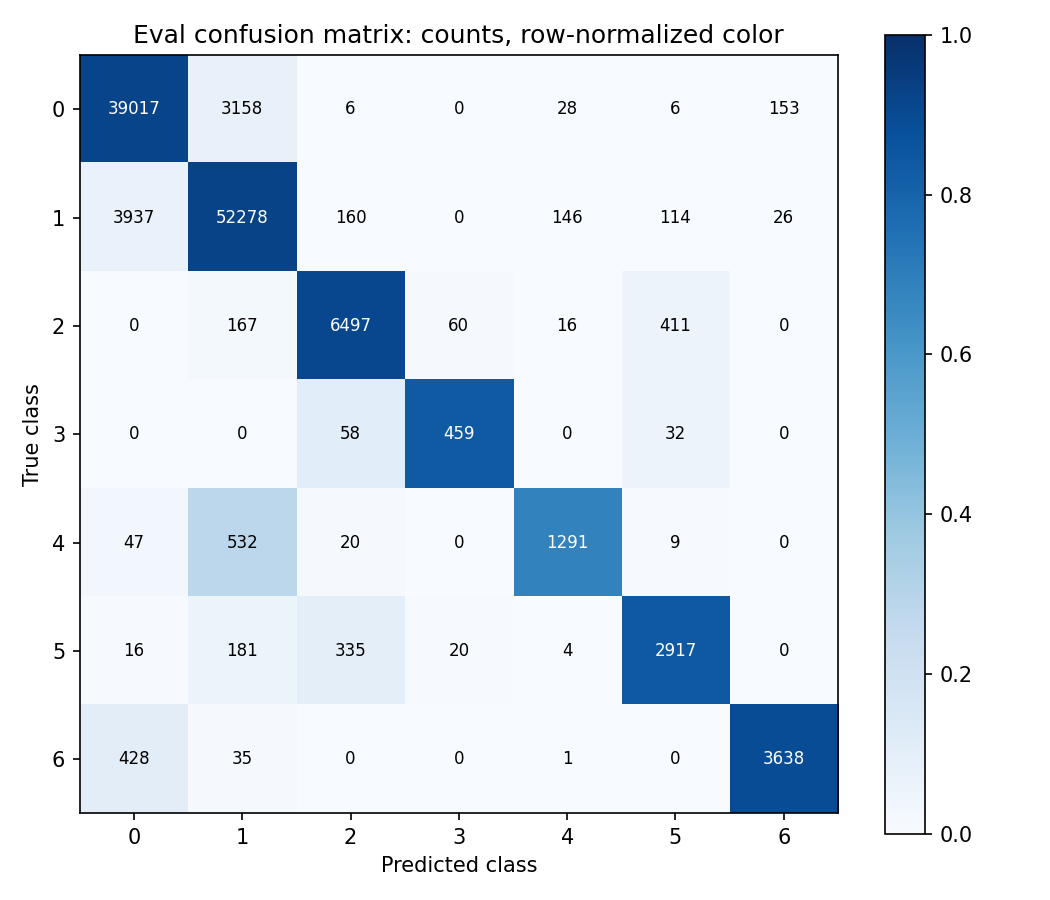

Hardest class: {'cls': 4, 'support': 1899, 'precision': 0.8687752355316285, 'recall': 0.6798314902580306, 'f1': 0.7627769571639587} most confused with: 1


In [14]:
official = json.loads((OUT_DIR / 'eval_result.json').read_text())
display(pd.DataFrame(official['per_class']))
cm = np.array(official['confusion_matrix'])
fig, ax = plt.subplots(figsize=(7,6))
image = ax.imshow(cm / cm.sum(1,keepdims=True), cmap='Blues', vmin=0, vmax=1)
for i in range(7):
    for j in range(7):
        ax.text(j,i,str(cm[i,j]),ha='center',va='center',fontsize=8,
                color='white' if cm[i,j]/cm[i].sum()>.5 else 'black')
ax.set(xlabel='Predicted class', ylabel='True class', title='Eval confusion matrix: counts, row-normalized color',
       xticks=range(7), yticks=range(7))
fig.colorbar(image,ax=ax); fig.tight_layout()
fig.savefig(OUT_DIR / 'figures/eval_confusion.png',dpi=150); plt.close(fig)
display(Image(filename=str(OUT_DIR / 'figures/eval_confusion.png')))
worst = min(official['per_class'],key=lambda x:x['f1'])
errors = cm[worst['cls']].copy(); errors[worst['cls']]=0
print('Hardest class:',worst,'most confused with:',int(errors.argmax()))


In [15]:
from report import make_deliverables
make_deliverables(results, base, final, scores, health, data, OUT_DIR, REPO_ROOT,
                  total_time=time.perf_counter()-START_TIME)
print('Artifacts written to', OUT_DIR)
print((OUT_DIR / 'REPORT.md').read_text())


Artifacts written to /home/sakana/Code/VinUni/Day16/K4-Track4-Day1-Neuralnetwork/submission_2A202602810
# Báo cáo Lab Day 1 — Nguyễn Thái Anh — 2A202602810

## 1. Thiết lập

Chạy trực tiếp trong Conda **base**, Python 3.13.11, PyTorch 2.10.0+cu128,
thiết bị **NVIDIA GeForce RTX 3060**. Forest CoverType chia theo metadata gốc: 464 809 train / 116 203 eval.
Từ train, tách phân tầng seed 42 thành 371 847 mẫu học và 92 962 mẫu validation.
Chỉ 10 cột liên tục được chuẩn hoá bằng thống kê của 371 847 mẫu học; giữ 44 cột one-hot.
Tập eval chỉ được mở sau khi ghi quyết định cấu hình vào `selection.json`.

Baseline `base-s1`: M-base 54→256→128→7, **47 879 tham số**, ReLU, bias;
CE, He cho mọi Linear, SGD momentum 0.9, lr **0.05**, batch 512,
20 epoch, dropout 0, không clip, FP32. Lr chọn bằng val trong 0.01 và 0.05.
Train loss đo ở eval mode trên 50 000 mẫu cố định seed 42; val dùng toàn tập.
Giữ batch cuối; không scheduler. Chọn checkpoint có **val loss thấp nhất**;
so cấu hình bằng macro-F1 t